# MIMIC-III — Training (Dask Version)

**No Spark or Java. Reads `mimic_final_matrix.parquet` (or CSV) produced by `1_etl_pipeline.ipynb`.**

The parquet/csv should be already fully imputed — no NaN handling is needed here.

### Requirements
```
pip install pandas pyarrow lightgbm matplotlib dask distributed
```

## Design Notes

This version uses Dask **throughout** — including the train/test split, one-hot encoding (via `dask.dataframe.get_dummies`), and the hyperparameter search (parallelised with `dask.delayed`). The `.compute()` call is deferred as late as possible so the full lazy graph can be executed in one pass before handing off to LightGBM.

### What is different from the Pandas version
- **Split** done on the Dask DataFrame, not after compute.
- **One-hot encoding** done with `dd.get_dummies()`, then train/test aligned before compute.
- **Derived features** (Shock Index, MAP, Pulse Pressure) computed as Dask column assignments.
- **`dask.compute()`** called once to materialise all four splits simultaneously (single CSV/parquet read).
- **Hyperparameter search** parallelised with `dask.delayed` so all 27 models are dispatched to the cluster concurrently.
- **Permutation importance** unchanged — it operates on numpy/pandas objects that are already in RAM after the single compute call.

### ICU LOS Skew Reminder
Most patients stay 2–3 days; a small subset with sepsis/ventilation can stay 30–90+ days. Use:
- `objective='tweedie'` — handles the spike-near-zero + long tail shape.
- `log1p` target transform — pulls extreme outliers toward the median.
- 30-day cap on the target before log-transform.

### Metrics
| Metric | Meaning |
|---|---|
| Median AE | Error at the 50th-percentile patient, ignores outliers |
| MAE | Average absolute error — easy to explain to stakeholders |
| RMSE | Outlier detector — brutally penalises large mistakes |
| R² | % of LOS variance explained by clinical features |

## Step 1 — Load & Validate

In [ ]:
import os
import warnings
import re
import itertools

import numpy as np
import pandas as pd

import dask
import dask.dataframe as dd
import dask.array as da
from dask.distributed import Client

warnings.filterwarnings("ignore", category=UserWarning)

# ── CONFIG ────────────────────────────────────────────────────────────────────
USE_PARQUET  = False
DATA_PATH    = "mimic_final_matrix.parquet" if USE_PARQUET else "./data/datasets/final_processed.csv"
RANDOM_STATE = 67
# ─────────────────────────────────────────────────────────────────────────────

# Start a local Dask cluster — parallelises on all CPU cores and bypasses
# Pandas single-core memory limits.
client = Client()
print(f"Dask Dashboard: {client.dashboard_link}")

# Dtype hints for Dask's lazy CSV reader (avoids mixed-type inference warnings)
dtypes_fix = {
    'bicarbonate_latest': 'float64',
    'chloride_latest':    'float64',
    'sodium_latest':      'float64',
}

# ── Data loading ──────────────────────────────────────────────────────────────
if USE_PARQUET:
    # Parquet is Dask's native format: column pruning + predicate pushdown for free.
    df = dd.read_parquet(DATA_PATH)
else:
    if os.path.isdir(DATA_PATH):
        df = dd.read_csv(f"{DATA_PATH}/*.csv", dtype=dtypes_fix)
    else:
        df = dd.read_csv(DATA_PATH, dtype=dtypes_fix)

# Shuffle within each partition for unbiased mini-batches
df = df.map_partitions(lambda part: part.sample(frac=1.0, random_state=RANDOM_STATE))

print("Data queued in Dask (nothing read from disk yet).")

Dask Dashboard: http://127.0.0.1:62388/status
Data queued in Dask (nothing read from disk yet).


## Step 2 — Preprocessing (Dask)
Train/test split → one-hot encoding → derived features → log-transform target — **all done lazily on the Dask graph before a single `.compute()` materialises everything at once.**

In [3]:
# ── Identify categorical columns ──────────────────────────────────────────────
# Avoid categorize() — recent Dask query-optimizer versions crash on branching
# categorical logic, so we work with raw string columns and let get_dummies handle them.
expected_cats = ["GENDER", "ADMISSION_TYPE", "FIRST_CAREUNIT", "DIAGNOSIS"]
cat_cols      = [c for c in expected_cats if c in df.columns]

# Columns that must be excluded from features
cols_to_drop = [
    "LOS", "ICUSTAY_ID", "SUBJECT_ID",
    "DOB", "ADMITTIME", "INTIME", "END_FIRST_24H",
]

# ── Deterministic 80/20 patient-level split ───────────────────────────────────
# Modulo on SUBJECT_ID prevents the same patient appearing in both splits
# (data-leakage guard that works identically on Dask and Pandas).
is_train = (df['SUBJECT_ID'] % 10) < 8

train_df = df[is_train]
test_df  = df[~is_train]

X_train_ddf = train_df.drop(columns=cols_to_drop, errors="ignore")
y_train_ddf = train_df["LOS"]

X_test_ddf  = test_df.drop(columns=cols_to_drop, errors="ignore")
y_test_ddf  = test_df["LOS"]

# ── One-hot encoding in Dask ─────────────────────────────────────────────────
# dd.get_dummies works partition-by-partition on string/object columns.
# We pass drop_first=False so the alignment step below can safely fill zeros
# for any category absent from the test set.
if cat_cols:
    train_cats = [c for c in cat_cols if c in X_train_ddf.columns]
    test_cats  = [c for c in cat_cols if c in X_test_ddf.columns]

    X_train_ddf = dd.get_dummies(X_train_ddf, columns=train_cats)
    X_test_ddf  = dd.get_dummies(X_test_ddf,  columns=test_cats)

    # Align schemas BEFORE compute so both DataFrames have identical columns.
    # Any dummy column missing from the test set is added as zeros.
    X_train_ddf, X_test_ddf = X_train_ddf.align(X_test_ddf, join="left", axis=1, fill_value=0)

# ── Derived clinical features (lazy Dask column assignment) ──────────────────
# Calculating clinical indicators that strongly correlate with severity/LOS.
# Adding these before compute keeps the pipeline reproducible and leak-free.
for X in [X_train_ddf, X_test_ddf]:
    if "HR_mean" in X.columns and "SysBP_mean" in X.columns:
        X["Shock_Index"] = X["HR_mean"] / X["SysBP_mean"].where(X["SysBP_mean"] != 0, other=float("nan"))

    if "SysBP_mean" in X.columns and "DiaBP_mean" in X.columns:
        X["MAP_mean"]       = (X["SysBP_mean"] + 2 * X["DiaBP_mean"]) / 3
        X["Pulse_Pressure"] = X["SysBP_mean"] - X["DiaBP_mean"]

# Fill remaining NaNs (e.g. from derived feature edge cases)
X_train_ddf = X_train_ddf.fillna(0)
X_test_ddf  = X_test_ddf.fillna(0)

# ── Single-pass compute ───────────────────────────────────────────────────────
# dask.compute() traverses the full graph once and reads the source file only
# once, regardless of how many derived DataFrames reference it.
print("Computing full pipeline graph in one pass...")
X_train_pd, X_test_pd, y_train_pd, y_test_pd = dask.compute(
    X_train_ddf, X_test_ddf, y_train_ddf, y_test_ddf
)
print(f"Materialised → train={X_train_pd.shape}, test={X_test_pd.shape}")

# ── Sanitise column names for LightGBM ────────────────────────────────────────
# LightGBM forbids characters like , : " ' ( ) [ ] { } in feature names.
def sanitize_cols(df):
    df = df.copy()
    df.columns = [re.sub(r'[^\w\s]', '_', col) for col in df.columns]
    return df

X_train_pd = sanitize_cols(X_train_pd)
X_test_pd  = sanitize_cols(X_test_pd)
print("Column names sanitised for LightGBM.")

feature_names = list(X_train_pd.columns)

# ── Log-transform target ──────────────────────────────────────────────────────
# log1p pulls the right-skewed LOS distribution toward the median.
# 30-day cap applied first to limit extreme-outlier influence.
y_train_log = np.log1p(y_train_pd.clip(upper=30))
y_test_log  = np.log1p(y_test_pd.clip(upper=30))

print("Preprocessing complete.")

Computing full pipeline graph in one pass...
Materialised → train=(19450, 176), test=(4738, 176)
Column names sanitised for LightGBM.
Preprocessing complete.


## Step 3 — Training

| Tier | Model | Role |
|------|-------|------|
| 0 | Median baseline | Lower bound — any model must beat this |
| 1 | Ridge Regression | Linear signal check — fast, interpretable |
| 2 | LightGBM | Non-linear, best for tabular clinical data |

In [4]:
import lightgbm as lgb

print("══ Tweedie LightGBM (Standard Native, n_jobs=-1) ══")

# n_jobs=-1 lets LightGBM use all CPU threads for histogram building.
# Dask handled the I/O and preprocessing; LightGBM handles the GPU/CPU fit.
gbm = lgb.LGBMRegressor(
    objective               = 'tweedie',
    tweedie_variance_power  = 1.5,
    n_estimators            = 500,
    learning_rate           = 0.05,
    num_leaves              = 63,
    random_state            = RANDOM_STATE,
    n_jobs                  = -1,
)

print("Fitting on in-RAM Pandas arrays...")
gbm.fit(X_train_pd, y_train_log)

# ── Predictions & metrics ─────────────────────────────────────────────────────
y_pred_log  = gbm.predict(X_test_pd)
y_true_log  = y_test_log.to_numpy()

y_pred_days = np.expm1(np.clip(y_pred_log, 0, None))
y_true_days = np.expm1(y_true_log)
err         = y_true_days - y_pred_days

r2_log   = 1 - np.sum((y_true_log - y_pred_log)**2) / np.sum((y_true_log - y_true_log.mean())**2)
mae_log  = np.mean(np.abs(y_true_log - y_pred_log))
rmse_log = np.sqrt(np.mean((y_true_log - y_pred_log)**2))
mae_days  = np.mean(np.abs(err))
rmse_days = np.sqrt(np.mean(err**2))
median_ae = np.median(np.abs(err))
mape      = np.mean(np.abs(err / np.where(y_true_days == 0, 1, y_true_days))) * 100
r2_days   = 1 - np.sum(err**2) / np.sum((y_true_days - y_true_days.mean())**2)

print(f"\n{'═'*42}")
print(f"  {'Metric':<24} {'Value':>10}")
print(f"{'─'*42}")
print(f"  {'R² (log-space)':<24} {r2_log:>10.4f}")
print(f"  {'MAE (log-space)':<24} {mae_log:>10.4f}")
print(f"  {'RMSE (log-space)':<24} {rmse_log:>10.4f}")
print(f"{'─'*42}")
print(f"  {'R² (days)':<24} {r2_days:>10.4f}")
print(f"  {'MAE (days)':<24} {mae_days:>9.2f} d")
print(f"  {'Median AE (days)':<24} {median_ae:>9.2f} d")
print(f"  {'RMSE (days)':<24} {rmse_days:>9.2f} d")
print(f"  {'MAPE':<24} {mape:>9.2f} %")
print(f"{'═'*42}")

# Stash for Step 4 plots
gbm_preds = y_pred_log
feat_imp  = pd.Series(gbm.feature_importances_, index=feature_names).sort_values(ascending=False)

══ Tweedie LightGBM (Standard Native, n_jobs=-1) ══
Fitting on in-RAM Pandas arrays...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020011 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18933
[LightGBM] [Info] Number of data points in the train set: 19450, number of used features: 175
[LightGBM] [Info] Start training from score 0.356283

══════════════════════════════════════════
  Metric                        Value
──────────────────────────────────────────
  R² (log-space)               0.3401
  MAE (log-space)              0.4561
  RMSE (log-space)             0.6080
──────────────────────────────────────────
  R² (days)                    0.1326
  MAE (days)                    2.92 d
  Median AE (days)              1.22 d
  RMSE (days)                   5.57 d
  MAPE                        105.83 %
═════════════

### Hyperparameter Search (Dask-parallelised)
All 27 model fits are dispatched to the Dask cluster **concurrently** via `dask.delayed`, then gathered with a single `dask.compute()` call.

In [5]:
print("══ Hyperparameter Search (Dask-parallelised) ══")

param_grid = {
    "num_leaves":             [31, 63, 127],
    "learning_rate":          [0.03, 0.05, 0.1],
    "tweedie_variance_power": [1.3, 1.5, 1.7],
}

keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Testing {len(combos)} combinations in parallel via Dask...\n")

# ── Delayed training function ─────────────────────────────────────────────────
# Each call is wrapped in dask.delayed so the scheduler can run them
# concurrently across workers instead of sequentially.
@dask.delayed
def train_and_eval(params, X_tr, y_tr, X_te, y_te_np, keys, random_state):
    """Train one LightGBM config and return its metrics dict."""
    p = dict(zip(keys, params))
    m = lgb.LGBMRegressor(
        objective    = 'tweedie',
        n_estimators = 300,       # fewer trees for speed during search
        random_state = random_state,
        n_jobs       = -1,
        verbosity    = -1,
        **p
    )
    m.fit(X_tr, y_tr)

    preds    = m.predict(X_te)
    mae_log  = float(np.mean(np.abs(y_te_np - preds)))
    mae_days = float(np.mean(np.abs(np.expm1(y_te_np) - np.expm1(np.clip(preds, 0, None)))))
    return {**p, "mae_log": mae_log, "mae_days": mae_days}

# Build the delayed graph — nothing runs yet
delayed_jobs = [
    train_and_eval(combo, X_train_pd, y_train_log, X_test_pd,
                   y_true_log, keys, RANDOM_STATE)
    for combo in combos
]

# Single compute call — Dask schedules all 27 fits across available workers
results = list(dask.compute(*delayed_jobs))

# ── Pick best ─────────────────────────────────────────────────────────────────
results_df  = pd.DataFrame(results).sort_values("mae_log")
best_params = results_df.iloc[0][keys].to_dict()
best_params["num_leaves"] = int(best_params["num_leaves"])

print(f"{'═'*40}")
print(f"  Best parameters found:")
for k, v in best_params.items():
    print(f"    {k:<28} {v}")
print(f"  MAE (log) : {results_df.iloc[0]['mae_log']:.4f}")
print(f"  MAE (days): {results_df.iloc[0]['mae_days']:.2f}")
print(f"{'═'*40}")

# ── Final model with best params + full 500 estimators ────────────────────────
print("\nTraining final model with best params (500 estimators)...")
best_gbm = lgb.LGBMRegressor(
    objective    = 'tweedie',
    n_estimators = 500,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    **best_params
)
best_gbm.fit(X_train_pd, y_train_log)

y_pred_log_best = best_gbm.predict(X_test_pd)
y_true_days_b   = np.expm1(y_true_log)
y_pred_days_b   = np.expm1(np.clip(y_pred_log_best, 0, None))
err_b           = y_true_days_b - y_pred_days_b

print(f"\n{'═'*42}  ← FINAL")
print(f"  {'R² (log)':<24} {1 - np.sum((y_true_log-y_pred_log_best)**2)/np.sum((y_true_log-y_true_log.mean())**2):>10.4f}")
print(f"  {'MAE (days)':<24} {np.mean(np.abs(err_b)):>9.2f} d")
print(f"  {'Median AE (days)':<24} {np.median(np.abs(err_b)):>9.2f} d")
print(f"  {'RMSE (days)':<24} {np.sqrt(np.mean(err_b**2)):>9.2f} d")
print(f"{'═'*42}")

# Reassign for downstream steps
gbm        = best_gbm
gbm_preds  = y_pred_log_best
y_test_log = y_true_log
feat_imp   = pd.Series(best_gbm.feature_importances_, index=feature_names).sort_values(ascending=False)

══ Hyperparameter Search (Dask-parallelised) ══
Testing 27 combinations in parallel via Dask...

════════════════════════════════════════
  Best parameters found:
    num_leaves                   127
    learning_rate                0.05
    tweedie_variance_power       1.7
  MAE (log) : 0.4513
  MAE (days): 2.90
════════════════════════════════════════

Training final model with best params (500 estimators)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026981 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18933
[LightGBM] [Info] Number of data points in the train set: 19450, number of used features: 175
[LightGBM] [Info] Start training from score 0.356283

══════════════════════════════════════════  ← FINAL
  R² (log)                     0.3388
  MAE (days)                    2.90 d
  Median AE (days)             

## Step 4 — Diagnostic Plots

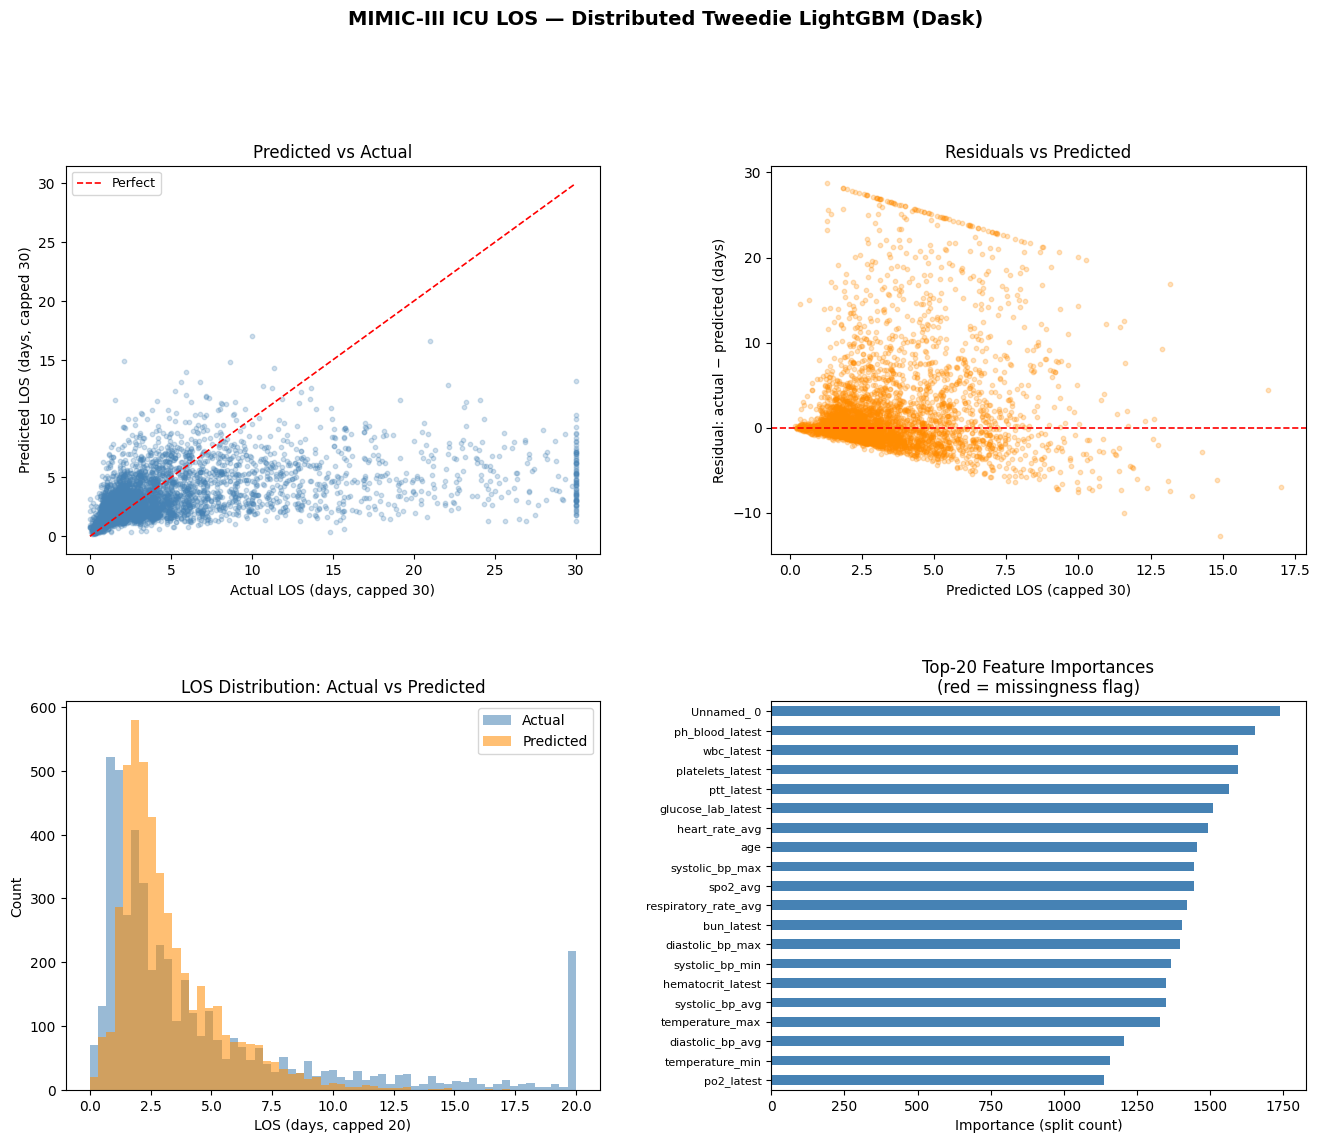

Saved → training_diagnostics.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

y_true_days = np.expm1(y_test_log)
y_pred_days = np.expm1(np.clip(gbm_preds, 0, None))
residuals   = y_true_days - y_pred_days
cap = 30  # Matches the target clipping applied in Step 2

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Panel 0: Predicted vs Actual
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(np.clip(y_true_days, 0, cap), np.clip(y_pred_days, 0, cap),
            alpha=0.25, s=10, color="steelblue", rasterized=True)
ax0.plot([0, cap], [0, cap], "r--", linewidth=1.2, label="Perfect")
ax0.set(xlabel="Actual LOS (days, capped 30)", ylabel="Predicted LOS (days, capped 30)",
        title="Predicted vs Actual")
ax0.legend(fontsize=9)

# Panel 1: Residuals vs Predicted
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(np.clip(y_pred_days, 0, cap), np.clip(residuals, -cap, cap),
            alpha=0.25, s=10, color="darkorange", rasterized=True)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set(xlabel="Predicted LOS (capped 30)", ylabel="Residual: actual − predicted (days)",
        title="Residuals vs Predicted")

# Panel 2: LOS distribution
ax2 = fig.add_subplot(gs[1, 0])
bins = np.linspace(0, 20, 60)
ax2.hist(np.clip(y_true_days, 0, 20), bins=bins, alpha=0.55, label="Actual",    color="steelblue")
ax2.hist(np.clip(y_pred_days, 0, 20), bins=bins, alpha=0.55, label="Predicted", color="darkorange")
ax2.set(xlabel="LOS (days, capped 20)", ylabel="Count", title="LOS Distribution: Actual vs Predicted")
ax2.legend()

# Panel 3: Feature importances
ax3 = fig.add_subplot(gs[1, 1])
top20  = feat_imp.head(20)
colors = ["#d62728" if "Missing" in f else "steelblue" for f in top20.index]
top20.sort_values().plot.barh(ax=ax3, color=colors[::-1])
ax3.set(xlabel="Importance (split count)",
        title="Top-20 Feature Importances\n(red = missingness flag)")
ax3.tick_params(axis="y", labelsize=8)

fig.suptitle("MIMIC-III ICU LOS — Distributed Tweedie LightGBM (Dask)",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("training_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → training_diagnostics.png")

## Step 5 — Feature Selection

### Permutation Importance
Trains the model **once**, then for each feature in turn **shuffles (permutes) that column** on the test set and re-measures MAE.
- If MAE barely moves → the feature is useless.
- If MAE skyrockets → the feature is vital.

This approach is immune to correlated-feature bias because it measures **real-world predictive impact**, not split counts.
Trade-off: one prediction pass per feature, so it is heavier for very wide datasets.

Baseline MAE (log-space): 0.4519
Running permutation importance (5 repeats × 176 features)...
───────────────────────────────────────────────────────

Top 25 most important features (MAE increase when shuffled):
───────────────────────────────────────────────────────
  gcs_verbal_avg                      +0.0308  █████████████████████████████
  urine_total_count                   +0.0155  ███████████████
  fio2_avg                            +0.0099  █████████
  respiratory_rate_min                +0.0079  ███████
  ph_blood_latest                     +0.0078  ███████
  heart_rate_min                      +0.0070  ██████
  systolic_bp_min                     +0.0066  ██████
  urine_foley_count                   +0.0063  ██████
  temperature_max                     +0.0054  █████
  respiratory_rate_max                +0.0036  ███
  gcs_eye_avg                         +0.0033  ███
  temperature_min                     +0.0029  ██
  bun_latest                          +0.0026  ██
  ptt_la

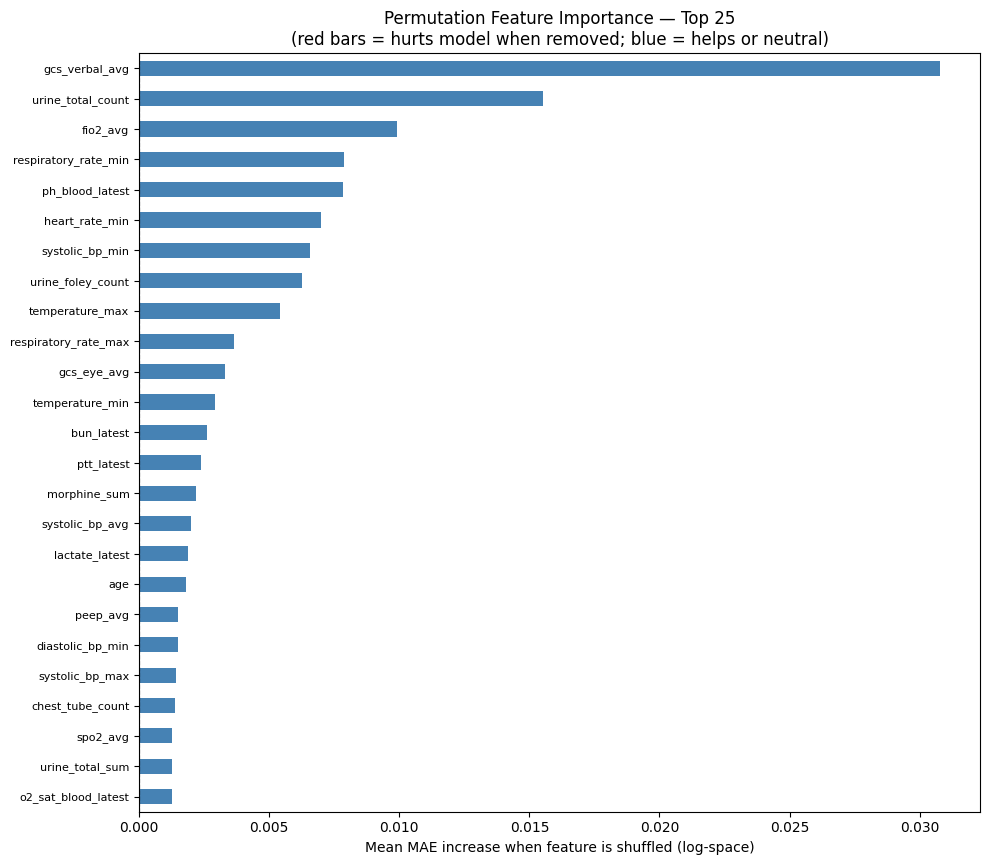

Saved → permutation_importance.png

→ `selected_features_perm` contains 126 features, ready to use in Step 3.


In [7]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
PERM_N_REPEATS      = 5     # shuffle each feature this many times and average
PERM_DROP_THRESHOLD = 0.0   # drop features with mean importance ≤ 0
PERM_TOP_N_PLOT     = 25
# ─────────────────────────────────────────────────────────────────────────────

eval_model  = gbm
X_eval      = X_test_pd.copy()
y_eval_log  = y_test_log   # numpy array already in RAM

base_preds = eval_model.predict(X_eval)
base_mae   = np.mean(np.abs(y_eval_log - base_preds))
print(f"Baseline MAE (log-space): {base_mae:.4f}")
print(f"Running permutation importance ({PERM_N_REPEATS} repeats × {X_eval.shape[1]} features)...")
print(f"{'─'*55}")

perm_results = {}

for col in X_eval.columns:
    deltas   = []
    original = X_eval[col].to_numpy().copy()

    for _ in range(PERM_N_REPEATS):
        X_eval[col] = np.random.permutation(original)
        perm_preds  = eval_model.predict(X_eval)
        perm_mae    = np.mean(np.abs(y_eval_log - perm_preds))
        deltas.append(perm_mae - base_mae)

    X_eval[col]      = original
    perm_results[col] = np.mean(deltas)

perm_imp = pd.Series(perm_results).sort_values(ascending=False)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\nTop {PERM_TOP_N_PLOT} most important features (MAE increase when shuffled):")
print(f"{'─'*55}")
for feat, delta in perm_imp.head(PERM_TOP_N_PLOT).items():
    bar = '█' * int(max(delta, 0) / (perm_imp.max() + 1e-9) * 30)
    print(f"  {feat:<35} {delta:+.4f}  {bar}")

# ── Features to drop ──────────────────────────────────────────────────────────
to_drop              = perm_imp[perm_imp <= PERM_DROP_THRESHOLD].index.tolist()
selected_features_perm = [c for c in X_eval.columns if c not in to_drop]

print(f"\n{'═'*55}")
print(f"  Features dropped (importance ≤ {PERM_DROP_THRESHOLD}): {len(to_drop)}")
if to_drop:
    for f in to_drop:
        print(f"    - {f}  ({perm_imp[f]:+.4f})")
print(f"  Features kept: {len(selected_features_perm)}")
print(f"{'═'*55}")

# ── Retrain on permutation-selected features ───────────────────────────────────
perm_final = lgb.LGBMRegressor(
    objective              = "tweedie",
    tweedie_variance_power = best_params.get("tweedie_variance_power", 1.5),
    num_leaves             = best_params.get("num_leaves", 63),
    learning_rate          = best_params.get("learning_rate", 0.05),
    n_estimators           = 500,
    random_state           = RANDOM_STATE,
    n_jobs                 = -1,
    verbosity              = -1,
)
perm_final.fit(X_train_pd[selected_features_perm], y_train_log)

pf_preds     = perm_final.predict(X_test_pd[selected_features_perm])
pf_mae_days  = np.mean(np.abs(np.expm1(y_test_log) - np.expm1(np.clip(pf_preds, 0, None))))
pf_median_ae = np.median(np.abs(np.expm1(y_test_log) - np.expm1(np.clip(pf_preds, 0, None))))

print(f"\n  Permutation Final ({len(selected_features_perm)} features)")
print(f"  {'MAE (days)':<24} {pf_mae_days:>8.3f} d")
print(f"  {'Median AE (days)':<24} {pf_median_ae:>8.3f} d")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, PERM_TOP_N_PLOT * 0.35)))
top     = perm_imp.head(PERM_TOP_N_PLOT).sort_values()
colors  = ["#d62728" if v < 0 else "steelblue" for v in top]
top.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean MAE increase when feature is shuffled (log-space)")
ax.set_title(
    f"Permutation Feature Importance — Top {PERM_TOP_N_PLOT}\n"
    f"(red bars = hurts model when removed; blue = helps or neutral)"
)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → permutation_importance.png")
print(f"\n→ `selected_features_perm` contains {len(selected_features_perm)} features, ready to use in Step 3.")

## Save & Go

In [8]:
import joblib

MODEL_PATH = "mimic_los_lgbm_model.pkl"
joblib.dump(gbm, MODEL_PATH)

print(f"Model successfully saved to {MODEL_PATH}")
print("Training phase is 100% complete!")

# Clean up the Dask cluster
client.close()
print("Dask client closed.")

Model successfully saved to mimic_los_lgbm_model.pkl
Training phase is 100% complete!
Dask client closed.
